# Breast Cancer Wisconsin Dataset - Exploratory Data Analysis

## Objective

This notebook performs an initial exploratory analysis of the Breast Cancer Wisconsin dataset.

The objectives are:

- Understand dataset structure
- Analyze feature distributions
- Identify missing values
- Detect duplicated samples
- Generate statistical summaries
- Understand target class distribution
- Identify important correlations
- Prepare insights before model training

## Dataset

The dataset used:

**Breast Cancer Wisconsin Diagnostic Dataset**

Source:
`sklearn.datasets.load_breast_cancer`

The dataset contains:

- 569 samples
- 30 numerical features
- Binary classification target

Target:

| Value | Meaning |
|---|---|
| 0 | Malignant |
| 1 | Benign |

---

## MLOps Context

EDA is an important step before:

- Data validation
- Feature engineering
- Model training
- MLflow experiment tracking

The objective is to understand the data before building the production pipeline.

In [1]:
# ============================================================================
# Imports
# ============================================================================

import os
import logging
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer


print("Libraries imported successfully")

Libraries imported successfully


# Project Directories

We create directories for generated reports.

Structure:

```
reports/

    ├── statistics/
    │
    └── figures/
```


Statistics will contain CSV files.

Figures will contain generated visualizations.

In [2]:
# ============================================================================
# Create report directories
# ============================================================================


BASE_DIR = Path("../")

REPORT_DIR = BASE_DIR / "reports"

STATISTICS_DIR = REPORT_DIR / "statistics"

FIGURES_DIR = REPORT_DIR / "figures"


STATISTICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("Report directories created")

print(STATISTICS_DIR)
print(FIGURES_DIR)

Report directories created
../reports/statistics
../reports/figures


# Logging Configuration

Logging helps track the execution of the analysis.

In production MLOps systems, logs are important for:

- debugging
- monitoring
- CI/CD pipelines
- reproducibility

In [3]:
# ============================================================================
# Logger
# ============================================================================


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)


logger = logging.getLogger(
    "breast_cancer_eda"
)


logger.info(
    "EDA notebook started"
)

2026-08-06 11:35:36,201 - INFO - EDA notebook started


# Load Dataset

The dataset is loaded using Scikit-Learn.

The function returns:

- feature matrix
- target labels
- feature names
- target names

We convert it into a Pandas DataFrame because Pandas provides:

- statistical functions
- filtering
- visualization support
- easier debugging

In [4]:
# ============================================================================
# Load Dataset
# ============================================================================


dataset = load_breast_cancer()


X = pd.DataFrame(
    dataset.data,
    columns=dataset.feature_names
)


y = pd.Series(
    dataset.target,
    name="target"
)


target_names = dataset.target_names


logger.info(
    "Dataset loaded successfully"
)


print(
    "Feature shape:",
    X.shape
)


print(
    "Target shape:",
    y.shape
)

2026-08-06 11:35:47,022 - INFO - Dataset loaded successfully


Feature shape: (569, 30)
Target shape: (569,)


# 1. Dataset Overview

This section provides a high-level overview:

- Number of samples
- Number of features
- Data types
- Memory usage
- Feature names
- Target information

In [5]:
# ============================================================================
# Dataset Overview
# ============================================================================


def dataset_overview(
    X: pd.DataFrame,
    y: pd.Series
):

    overview = {

        "number_of_samples":
            X.shape[0],

        "number_of_features":
            X.shape[1],

        "feature_memory_usage_MB":
            round(
                X.memory_usage().sum()
                /
                (1024 ** 2),
                3
            ),

        "missing_values":
            X.isnull().sum().sum(),

        "duplicate_rows":
            X.duplicated().sum(),

        "target_classes":
            y.nunique()

    }


    return pd.DataFrame(
        overview.items(),
        columns=[
            "metric",
            "value"
        ]
    )


overview_df = dataset_overview(
    X,
    y
)


overview_df

,metric,value
0,number_of_samples,569.00
1,number_of_features,30.00
2,feature_memory_usage_MB,0.13
3,missing_values,0.00
4,duplicate_rows,0.00
5,target_classes,2.00


## Feature Information

The dataset contains 30 numerical medical measurements.

Examples:

- radius
- texture
- perimeter
- area
- smoothness
- compactness
- symmetry

All features are continuous numerical variables.

In [6]:
# ============================================================================
# Feature Information
# ============================================================================


feature_information = pd.DataFrame(
    {
        "feature":
            X.columns,

        "dtype":
            X.dtypes.astype(str).values,

        "unique_values":
            [
                X[col].nunique()
                for col in X.columns
            ]

    }
)


feature_information

,feature,dtype,unique_values
0,mean radius,float64,456
1,mean texture,float64,479
2,mean perimeter,float64,522
3,mean area,float64,539
4,mean smoothness,float64,474
5,mean compactness,float64,537
6,mean concavity,float64,537
7,mean concave points,float64,542
8,mean symmetry,float64,432
9,mean fractal dimension,float64,499


In [7]:
# Save overview report

overview_df.to_csv(
    STATISTICS_DIR /
    "dataset_overview.csv",
    index=False
)


feature_information.to_csv(
    STATISTICS_DIR /
    "feature_information.csv",
    index=False
)


logger.info(
    "Dataset overview exported"
)

2026-08-06 11:36:17,694 - INFO - Dataset overview exported


# Summary

Completed:

✅ Project setup  
✅ Logging configuration  
✅ Dataset loading  
✅ Dataset overview  
✅ Feature information export  

Generated files:

```
 reports/

└── statistics/
       ├── dataset_overview.csv
       └── feature_information.csv

```

# 2. Missing Value Analysis

Missing values can negatively impact machine learning models.

This analysis checks:

- Number of missing values per feature
- Percentage of missing values
- Visualization of missing data

The Breast Cancer Wisconsin dataset is expected to be clean,
but validating this step is important in a production ML pipeline.

In [8]:
# ============================================================================
# Missing Value Analysis
# ============================================================================


def missing_value_analysis(
    df: pd.DataFrame
):

    missing_count = df.isnull().sum()

    missing_percentage = (
        missing_count
        /
        len(df)
        *
        100
    )


    missing_report = pd.DataFrame(
        {
            "feature": df.columns,

            "missing_count":
                missing_count.values,

            "missing_percentage":
                missing_percentage.values
        }
    )


    missing_report = (
        missing_report
        .sort_values(
            by="missing_count",
            ascending=False
        )
        .reset_index(drop=True)
    )


    return missing_report



missing_report = missing_value_analysis(
    X
)


missing_report.head(10)

,feature,missing_count,missing_percentage
0,mean radius,0,0.0
1,mean texture,0,0.0
2,worst symmetry,0,0.0
3,worst concave points,0,0.0
4,worst concavity,0,0.0
5,worst compactness,0,0.0
6,worst smoothness,0,0.0
7,worst area,0,0.0
8,worst perimeter,0,0.0
9,worst texture,0,0.0


## Missing Value Interpretation

A feature is considered problematic when:

- Missing percentage is high
- Missing values are not random
- Important medical variables are affected


Possible strategies:

| Situation | Solution |
|---|---|
| Few missing values | Remove rows |
| Numerical features | Mean/Median imputation |
| Categorical features | Most frequent value |
| Large missing blocks | Investigate data source |


For this dataset, we expect:
   Missing values = 0

<Figure size 1200x500 with 0 Axes>

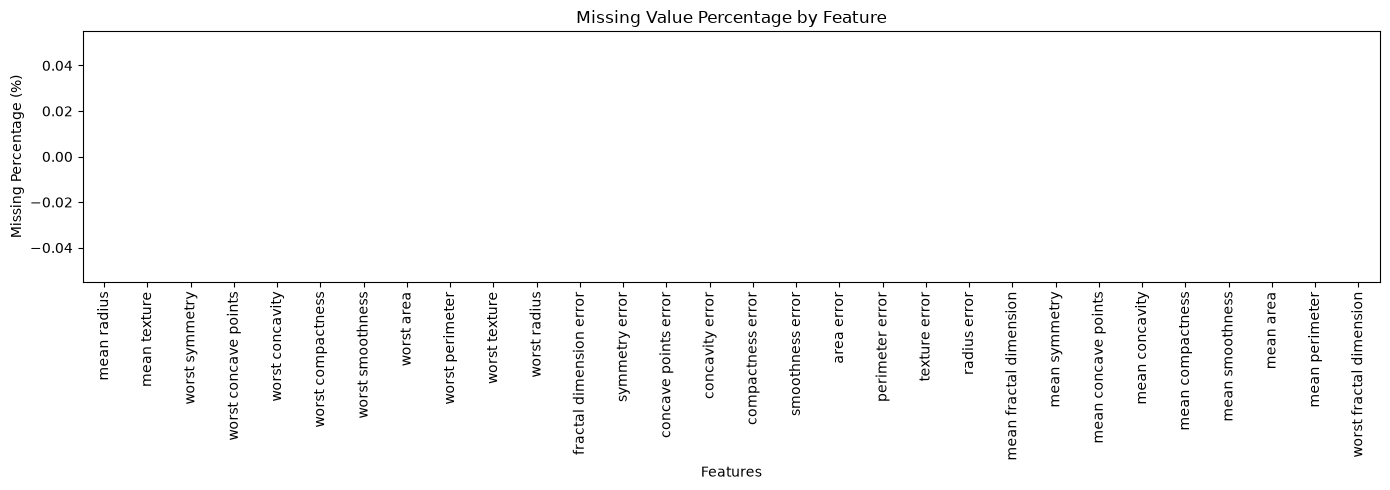

In [9]:
# ============================================================================
# Missing Value Visualization
# ============================================================================


plt.figure(
    figsize=(12,5)
)


missing_report.plot(
    x="feature",
    y="missing_percentage",
    kind="bar",
    figsize=(14,5),
    legend=False
)


plt.title(
    "Missing Value Percentage by Feature"
)


plt.ylabel(
    "Missing Percentage (%)"
)


plt.xlabel(
    "Features"
)


plt.xticks(
    rotation=90
)


plt.tight_layout()


plt.show()

In [10]:
# Export missing value report


missing_report.to_csv(
    STATISTICS_DIR /
    "missing_value_analysis.csv",
    index=False
)


logger.info(
    "Missing value analysis exported"
)

2026-08-06 11:36:23,013 - INFO - Missing value analysis exported


# 3. Duplicate Analysis

Duplicate samples can create problems:

- Data leakage
- Artificially high accuracy
- Poor generalization

We analyze:

- Number of duplicate rows
- Duplicate percentage

In [11]:
# ============================================================================
# Duplicate Analysis
# ============================================================================


def duplicate_analysis(
    df: pd.DataFrame
):

    duplicate_count = (
        df.duplicated()
        .sum()
    )


    duplicate_percentage = (
        duplicate_count
        /
        len(df)
        *
        100
    )


    report = pd.DataFrame(
        {
            "metric":
            [
                "duplicate_rows",
                "duplicate_percentage"
            ],

            "value":
            [
                duplicate_count,
                duplicate_percentage
            ]
        }
    )


    return report



duplicate_report = duplicate_analysis(
    X
)


duplicate_report

,metric,value
0,duplicate_rows,0.0
1,duplicate_percentage,0.0


In [12]:
# Export duplicate report


duplicate_report.to_csv(
    STATISTICS_DIR /
    "duplicate_analysis.csv",
    index=False
)


logger.info(
    "Duplicate analysis exported"
)

2026-08-06 11:36:23,084 - INFO - Duplicate analysis exported


# 4. Descriptive Statistics

Descriptive statistics summarize the distribution of numerical features.

We analyze:

- Count
- Mean
- Standard deviation
- Minimum
- Quartiles
- Maximum



In [13]:
# ============================================================================
# Descriptive Statistics
# ============================================================================


descriptive_statistics = (
    X.describe()
    .T
)


descriptive_statistics

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## Understanding the Statistics

### Mean

Average value:

\[
mean = \frac{\sum x_i}{n}
\]


### Standard Deviation

Measures feature variability.

High standard deviation:

- Feature values are spread out.


Low standard deviation:

- Feature values are concentrated.


### Quartiles

Used to understand distribution:


In [14]:
# Add additional descriptive metrics


descriptive_statistics["median"] = (
    X.median()
)


descriptive_statistics["variance"] = (
    X.var()
)


descriptive_statistics["range"] = (
    X.max()
    -
    X.min()
)


descriptive_statistics

,count,mean,std,min,25%,50%,75%,max,median,variance,range
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000,13.370000,12.418920,21.129000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000,18.840000,18.498909,29.570000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000,86.240000,590.440480,144.710000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000,551.100000,123843.554318,2357.500000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340,0.095870,0.000198,0.110770
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540,0.092630,0.002789,0.326020
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680,0.061540,0.006355,0.426800
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120,0.033500,0.001506,0.201200
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400,0.179200,0.000752,0.198000
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744,0.061540,0.000050,0.047480


In [15]:
# Export descriptive statistics


descriptive_statistics.to_csv(
    STATISTICS_DIR /
    "descriptive_statistics.csv"
)


logger.info(
    "Descriptive statistics exported"
)

2026-08-06 11:36:23,444 - INFO - Descriptive statistics exported


# Response 2 Completed

Implemented:

✅ Missing value analysis  
✅ Missing value visualization  
✅ Missing value CSV export  

✅ Duplicate detection  
✅ Duplicate percentage calculation  

✅ Descriptive statistics  
✅ Median calculation  
✅ Variance calculation  
✅ Feature range calculation  


Generated reports:

```
reports/
└── statistics/
      ├── missing_value_analysis.csv
      ├── duplicate_analysis.csv
      └── descriptive_statistics.csv
```


# 5. Advanced Statistical Analysis

Basic statistics describe the central tendency and spread.

Advanced statistics help us understand:

- Distribution shape
- Feature asymmetry
- Extreme values
- Feature variability

We calculate:

## Skewness

Measures the asymmetry of a distribution.

Interpretation:
```
Skewness ≈ 0
→ Symmetric distribution

Positive skew
→ Long tail on the right

Negative skew
→ Long tail on the left
```



---

## Kurtosis

Measures the "tail heaviness" of a distribution.

High kurtosis:

- More extreme values
- Higher probability of outliers

Low kurtosis:

- More uniform distribution

---

## Coefficient of Variation (CV)

Measures relative variability:

\[
CV = \frac{standard\ deviation}{mean}
\]

Useful when comparing features with different scales.

In [16]:
# ============================================================================
# Advanced Statistics
# ============================================================================


def advanced_statistics(
    df: pd.DataFrame
):

    statistics = pd.DataFrame(
        index=df.columns
    )


    statistics["mean"] = (
        df.mean()
    )


    statistics["median"] = (
        df.median()
    )


    statistics["variance"] = (
        df.var()
    )


    statistics["std"] = (
        df.std()
    )


    statistics["skewness"] = (
        df.skew()
    )


    statistics["kurtosis"] = (
        df.kurtosis()
    )


    statistics["coefficient_of_variation"] = (
        df.std()
        /
        df.mean()
    )


    statistics["min"] = (
        df.min()
    )


    statistics["max"] = (
        df.max()
    )


    return (
        statistics
        .sort_values(
            by="coefficient_of_variation",
            ascending=False
        )
    )



advanced_stats = advanced_statistics(
    X
)


advanced_stats.head(10)

,mean,median,variance,std,skewness,kurtosis,coefficient_of_variation,min,max
area error,40.337079,24.530000,2069.431583,45.491006,5.447186,49.209077,1.127771,6.802000,542.20000
concavity error,0.031894,0.025890,0.000911,0.030186,5.110463,48.861395,0.946458,0.000000,0.39600
mean concavity,0.088799,0.061540,0.006355,0.079720,1.401180,1.998638,0.897753,0.000000,0.42680
mean concave points,0.048919,0.033500,0.001506,0.038803,1.171180,1.066556,0.793204,0.000000,0.20120
worst concavity,0.272188,0.226700,0.043524,0.208624,1.150237,1.615253,0.766470,0.000000,1.25200
perimeter error,2.866059,2.287000,4.087896,2.021855,3.443615,21.401905,0.705448,0.757000,21.98000
compactness error,0.025478,0.020450,0.000321,0.017908,1.902221,5.106252,0.702884,0.002252,0.13540
fractal dimension error,0.003795,0.003187,0.000007,0.002646,3.923969,26.280847,0.697270,0.000895,0.02984
radius error,0.405172,0.324200,0.076902,0.277313,3.088612,17.686726,0.684432,0.111500,2.87300
worst area,880.583128,686.500000,324167.385102,569.356993,1.859373,4.396395,0.646568,185.200000,4254.00000


## Interpretation of Advanced Statistics

### High coefficient of variation

Features with high CV have:

- Large relative variability
- Potential importance for classification
- Possible need for scaling


### High skewness

Highly skewed features may require:

- Transformation
- Log scaling
- Robust preprocessing


### High kurtosis

Features with high kurtosis may contain:

- Extreme measurements
- Outliers

In [17]:
# Export advanced statistics


advanced_stats.to_csv(
    STATISTICS_DIR /
    "advanced_statistics.csv"
)


logger.info(
    "Advanced statistics exported"
)

2026-08-06 11:36:24,309 - INFO - Advanced statistics exported


# 6. Correlation Analysis

Correlation measures the relationship between numerical features.

The Pearson correlation coefficient:

\[
-1 \leq correlation \leq 1
\]


Interpretation:

| Value | Meaning |
|---|---|
| 1 | Perfect positive correlation |
| 0 | No linear relationship |
| -1 | Perfect negative correlation |


Why analyze correlation?

Highly correlated features may:

- contain redundant information
- increase model complexity
- create multicollinearity problems for some algorithms


Although Random Forest handles correlation well,
this analysis helps understand the dataset.

In [18]:
# ============================================================================
# Correlation Matrix
# ============================================================================


correlation_matrix = (
    X.corr()
)


correlation_matrix.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean radius,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
mean texture,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
mean perimeter,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
mean area,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
mean smoothness,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316


In [19]:
# Save correlation matrix


correlation_matrix.to_csv(
    STATISTICS_DIR /
    "correlation_matrix.csv"
)


logger.info(
    "Correlation matrix exported"
)

2026-08-06 11:36:25,750 - INFO - Correlation matrix exported


# 7. Highly Correlated Features

We identify feature pairs with strong correlation.

Threshold:

**|correlation| >= 0.85**


These features may contain similar information.

In [20]:
# ============================================================================
# Highly Correlated Features
# ============================================================================


def find_highly_correlated_features(
    correlation_matrix,
    threshold=0.85
):

    correlated_features = []


    columns = correlation_matrix.columns


    for i in range(len(columns)):

        for j in range(i+1, len(columns)):

            correlation = (
                correlation_matrix.iloc[i,j]
            )


            if abs(correlation) >= threshold:

                correlated_features.append(
                    {
                        "feature_1":
                            columns[i],

                        "feature_2":
                            columns[j],

                        "correlation":
                            correlation
                    }
                )


    return pd.DataFrame(
        correlated_features
    )



high_correlation = (
    find_highly_correlated_features(
        correlation_matrix
    )
)


high_correlation.head(20)

,feature_1,feature_2,correlation
0,mean radius,mean perimeter,0.997855
1,mean radius,mean area,0.987357
2,mean radius,worst radius,0.969539
3,mean radius,worst perimeter,0.965137
4,mean radius,worst area,0.941082
5,mean texture,worst texture,0.912045
6,mean perimeter,mean area,0.986507
7,mean perimeter,mean concave points,0.850977
8,mean perimeter,worst radius,0.969476
9,mean perimeter,worst perimeter,0.970387


In [21]:
# Export highly correlated features


high_correlation.to_csv(
    STATISTICS_DIR /
    "highly_correlated_features.csv",
    index=False
)


logger.info(
    "Highly correlated features exported"
)

2026-08-06 11:36:27,775 - INFO - Highly correlated features exported


# 8. Correlation Heatmap Visualization

The heatmap provides a visual overview of:

- Positive relationships
- Negative relationships
- Feature clusters


This visualization will help identify:

- redundant features
- groups of related measurements
- potential feature engineering opportunities

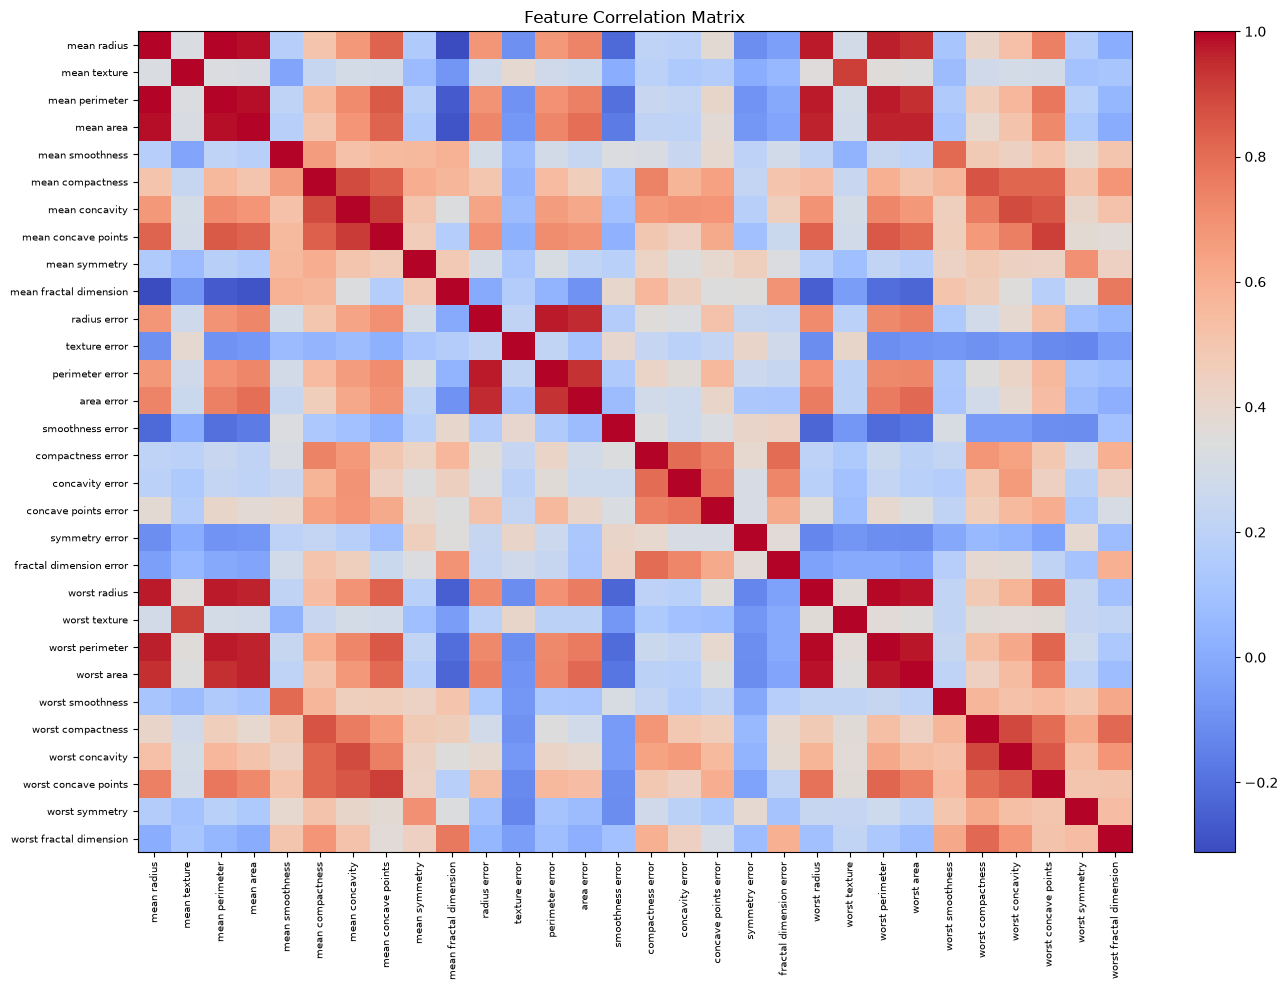

In [22]:
# ============================================================================
# Correlation Heatmap
# ============================================================================


plt.figure(
    figsize=(14,10)
)


plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)


plt.colorbar()


plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90,
    fontsize=7
)


plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    fontsize=7
)


plt.title(
    "Feature Correlation Matrix"
)


plt.tight_layout()


plt.show()

# Response 3 Completed

Implemented:

✅ Advanced statistics

Including:

- Mean
- Median
- Variance
- Standard deviation
- Skewness
- Kurtosis
- Coefficient of variation


✅ Correlation analysis

Generated:

```
 reports/statistics/
         ├── advanced_statistics.csv
         ├── correlation_matrix.csv
         └── highly_correlated_features.csv
```


# 8. Target Distribution Analysis

The target variable represents the diagnosis:

| Value | Diagnosis |
|---|---|
| 0 | Malignant |
| 1 | Benign |

Before training a classification model, we need to check:

- Class balance
- Possible imbalance problems
- Number of samples per class

A highly imbalanced dataset can affect:

- Accuracy
- Model training
- Evaluation metrics

In [23]:
# ============================================================================
# Target Distribution
# ============================================================================


target_distribution = (
    y.value_counts()
    .sort_index()
)


target_distribution

target
0    212
1    357
Name: count, dtype: int64

In [24]:
# Add target labels


target_distribution_df = pd.DataFrame(
    {
        "class_id":
            target_distribution.index,

        "count":
            target_distribution.values
    }
)


target_distribution_df["class_name"] = (
    target_distribution_df["class_id"]
    .map(
        {
            0: "Malignant",
            1: "Benign"
        }
    )
)


target_distribution_df

,class_id,count,class_name
0,0,212,Malignant
1,1,357,Benign


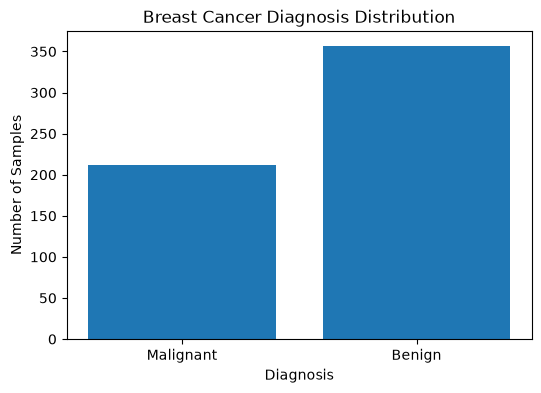

In [25]:
# ============================================================================
# Target Distribution Visualization
# ============================================================================


plt.figure(
    figsize=(6,4)
)


plt.bar(
    target_distribution_df["class_name"],
    target_distribution_df["count"]
)


plt.title(
    "Breast Cancer Diagnosis Distribution"
)


plt.xlabel(
    "Diagnosis"
)


plt.ylabel(
    "Number of Samples"
)


plt.show()

In [26]:
# Export target distribution


target_distribution_df.to_csv(
    STATISTICS_DIR /
    "target_distribution.csv",
    index=False
)


logger.info(
    "Target distribution exported"
)

2026-08-06 11:36:34,042 - INFO - Target distribution exported


# 9. Outlier Analysis

Outliers are observations that differ significantly from other samples.

They can represent:

- Measurement errors
- Rare medical cases
- Extreme biological variation


We use two methods:

## 1. IQR Method

The Interquartile Range:

\[
IQR = Q3 - Q1
\]


Outlier boundaries:

\[
Lower = Q1 - 1.5 \times IQR
\]

\[
Upper = Q3 + 1.5 \times IQR
\]


## 2. Z-score Method

Measures how far a value is from the mean:

\[
Z = \frac{x-\mu}{\sigma}
\]


Common threshold:

|Z-score| > 3



indicates a potential outlier.


In [27]:
# ============================================================================
# IQR Outlier Detection
# ============================================================================


def detect_iqr_outliers(
    df: pd.DataFrame
):

    results = []


    for column in df.columns:

        Q1 = df[column].quantile(0.25)

        Q3 = df[column].quantile(0.75)

        IQR = Q3 - Q1


        lower_bound = (
            Q1 - 1.5 * IQR
        )

        upper_bound = (
            Q3 + 1.5 * IQR
        )


        outliers = df[
            (df[column] < lower_bound)
            |
            (df[column] > upper_bound)
        ]


        results.append(
            {
                "feature":
                    column,

                "outlier_count":
                    len(outliers),

                "outlier_percentage":
                    len(outliers)
                    /
                    len(df)
                    *
                    100,

                "lower_bound":
                    lower_bound,

                "upper_bound":
                    upper_bound
            }
        )


    return pd.DataFrame(results)



iqr_outliers = detect_iqr_outliers(
    X
)


iqr_outliers.sort_values(
    "outlier_count",
    ascending=False
).head(10)

,feature,outlier_count,outlier_percentage,lower_bound,upper_bound
13,area error,65,11.423550,-23.160000,86.200000
10,radius error,38,6.678383,-0.137350,0.848650
12,perimeter error,38,6.678383,-1.020500,5.983500
23,worst area,35,6.151142,-337.750000,1937.050000
14,smoothness error,30,5.272408,0.000703,0.012612
15,compactness error,28,4.920914,-0.015975,0.061505
19,fractal dimension error,28,4.920914,-0.001217,0.008023
18,symmetry error,27,4.745167,0.002680,0.035960
3,mean area,25,4.393673,-123.300000,1326.300000
29,worst fractal dimension,24,4.217926,0.040530,0.123010


In [28]:
# Export IQR analysis


iqr_outliers.to_csv(
    STATISTICS_DIR /
    "iqr_outlier_analysis.csv",
    index=False
)


logger.info(
    "IQR outlier analysis exported"
)

2026-08-06 11:36:35,940 - INFO - IQR outlier analysis exported


In [29]:
# ============================================================================
# Z-score Outlier Detection
# ============================================================================


def detect_zscore_outliers(
    df: pd.DataFrame,
    threshold=3
):

    results = []


    for column in df.columns:

        mean = df[column].mean()

        std = df[column].std()


        z_scores = (
            (df[column] - mean)
            /
            std
        )


        outlier_count = (
            abs(z_scores) > threshold
        ).sum()


        results.append(
            {
                "feature":
                    column,

                "outlier_count":
                    outlier_count,

                "outlier_percentage":
                    outlier_count
                    /
                    len(df)
                    *
                    100
            }
        )


    return pd.DataFrame(results)



zscore_outliers = detect_zscore_outliers(
    X
)


zscore_outliers.sort_values(
    "outlier_count",
    ascending=False
).head(10)

,feature,outlier_count,outlier_percentage
15,compactness error,12,2.108963
18,symmetry error,11,1.933216
25,worst compactness,10,1.757469
23,worst area,10,1.757469
19,fractal dimension error,10,1.757469
11,texture error,9,1.581722
28,worst symmetry,9,1.581722
29,worst fractal dimension,9,1.581722
5,mean compactness,9,1.581722
6,mean concavity,9,1.581722


In [30]:
# Export Z-score results


zscore_outliers.to_csv(
    STATISTICS_DIR /
    "zscore_outlier_analysis.csv",
    index=False
)


logger.info(
    "Z-score analysis exported"
)

2026-08-06 11:36:37,339 - INFO - Z-score analysis exported


# 10. PCA Analysis

The dataset contains:

  30 features



Visualization in 30 dimensions is impossible.

Principal Component Analysis (PCA) reduces dimensionality.

Example:


30 dimensions

      ↓ PCA

2 dimensions

      ↓

Visualization




PCA is useful for:

- Understanding data structure
- Visualizing class separation
- Detecting clusters
- Feature compression


In [31]:
# ============================================================================
# PCA Analysis
# ============================================================================


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA



# Standardization before PCA

scaler = StandardScaler()


X_scaled = scaler.fit_transform(
    X
)


pca = PCA(
    n_components=2
)


X_pca = pca.fit_transform(
    X_scaled
)


pca_df = pd.DataFrame(
    {
        "PC1":
            X_pca[:,0],

        "PC2":
            X_pca[:,1],

        "target":
            y
    }
)


pca_df.head()

,PC1,PC2,target
0,9.192837,1.948583,0
1,2.387802,-3.768172,0
2,5.733896,-1.075174,0
3,7.122953,10.275589,0
4,3.935302,-1.948072,0


In [32]:
# Explained variance


explained_variance = pd.DataFrame(
    {
        "component":
            [
                "PC1",
                "PC2"
            ],

        "variance_ratio":
            pca.explained_variance_ratio_
    }
)


explained_variance

,component,variance_ratio
0,PC1,0.442720
1,PC2,0.189712


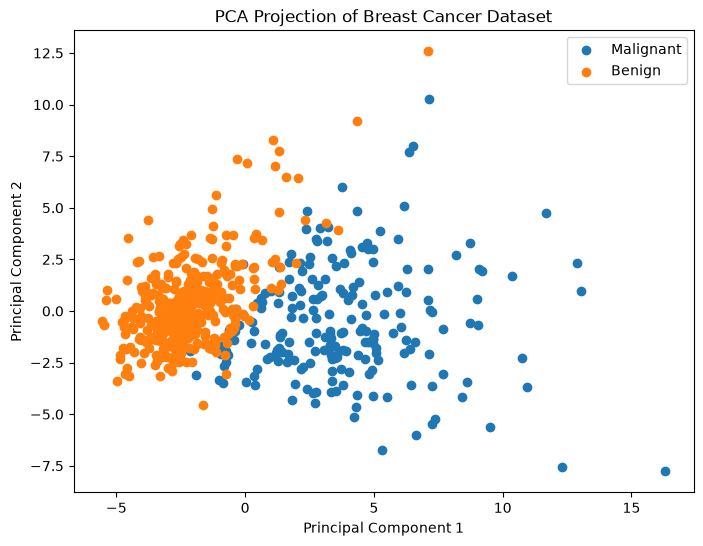

In [33]:
# PCA Visualization


plt.figure(
    figsize=(8,6)
)


for label, name in [
    (0, "Malignant"),
    (1, "Benign")
]:

    subset = pca_df[
        pca_df["target"] == label
    ]


    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=name
    )


plt.title(
    "PCA Projection of Breast Cancer Dataset"
)


plt.xlabel(
    "Principal Component 1"
)


plt.ylabel(
    "Principal Component 2"
)


plt.legend()


plt.show()

In [34]:
# Export PCA results


pca_df.to_csv(
    STATISTICS_DIR /
    "pca_projection.csv",
    index=False
)


explained_variance.to_csv(
    STATISTICS_DIR /
    "pca_explained_variance.csv",
    index=False
)


logger.info(
    "PCA analysis exported"
)

2026-08-06 11:36:39,861 - INFO - PCA analysis exported


# Response 4 Completed

Implemented:

## Target Analysis

✅ Class distribution  
✅ Class balance visualization  
✅ CSV export  


## Outlier Detection

Implemented:

✅ IQR method

Generated:

iqr_outlier_analysis.csv




✅ Z-score method

Generated:

zscore_outlier_analysis.csv



## PCA Analysis

Implemented:

✅ Feature standardization  
✅ PCA dimensionality reduction  
✅ Explained variance calculation  
✅ 2D visualization  


Generated:


reports/statistics/

        ├── target_distribution.csv
        ├── iqr_outlier_analysis.csv
        ├── zscore_outlier_analysis.csv
        ├── pca_projection.csv
        └── pca_explained_variance.csv


In [35]:
# ============================================================================
# Dataset Summary Report
# ============================================================================


def generate_dataset_summary(
    X: pd.DataFrame,
    y: pd.Series
):

    summary = {

        "Dataset name":
            "Breast Cancer Wisconsin Diagnostic Dataset",

        "Number of samples":
            X.shape[0],

        "Number of features":
            X.shape[1],

        "Feature type":
            "Numerical",

        "Target classes":
            y.nunique(),

        "Missing values":
            X.isnull().sum().sum(),

        "Duplicate samples":
            X.duplicated().sum(),

        "Memory usage MB":
            round(
                X.memory_usage().sum()
                /
                (1024 ** 2),
                3
            )
    }


    return summary



dataset_summary = generate_dataset_summary(
    X,
    y
)


dataset_summary

{'Dataset name': 'Breast Cancer Wisconsin Diagnostic Dataset',
 'Number of samples': 569,
 'Number of features': 30,
 'Feature type': 'Numerical',
 'Target classes': 2,
 'Missing values': np.int64(0),
 'Duplicate samples': np.int64(0),
 'Memory usage MB': np.float64(0.13)}

# 12. Generate Markdown Report

The report contains:

- Dataset information
- Data quality checks
- Statistical analysis results
- Modeling preparation notes

This creates a reproducible artifact.

In [36]:
# ============================================================================
# Markdown Report Generator
# ============================================================================


def generate_markdown_report(
    summary: dict,
    output_path
):

    report = f"""
# Breast Cancer Dataset - EDA Report


## Dataset Overview


| Metric | Value |
|---|---|
| Dataset | {summary['Dataset name']} |
| Samples | {summary['Number of samples']} |
| Features | {summary['Number of features']} |
| Feature Type | {summary['Feature type']} |
| Target Classes | {summary['Target classes']} |
| Missing Values | {summary['Missing values']} |
| Duplicate Samples | {summary['Duplicate samples']} |
| Memory Usage MB | {summary['Memory usage MB']} |



# Data Quality Analysis


## Missing Values

Missing value analysis was performed.

Result:

- Missing values detected:
  {summary['Missing values']}



## Duplicate Analysis

Duplicate samples:

{summary['Duplicate samples']}



# Statistical Analysis


The following statistics were generated:


- Descriptive statistics
- Variance
- Skewness
- Kurtosis
- Coefficient of variation



# Feature Relationship Analysis


Performed:

- Correlation matrix analysis
- Highly correlated feature detection



# Outlier Analysis


Methods used:

- Interquartile Range (IQR)
- Z-score analysis



# Dimensionality Reduction


Principal Component Analysis (PCA):

- Reduced dimensionality
- Created 2D visualization
- Calculated explained variance



# Conclusion


The dataset has been validated and analyzed.

The next step is:

1. Model training
2. MLflow experiment tracking
3. Model evaluation
4. Deployment with FastAPI


"""


    with open(
        output_path,
        "w",
        encoding="utf-8"
    ) as file:

        file.write(report)



    return output_path

In [37]:
# Generate report


eda_report_path = (
    REPORT_DIR /
    "EDA_Report.md"
)


generate_markdown_report(
    dataset_summary,
    eda_report_path
)


logger.info(
    "EDA Markdown report generated"
)


print(
    eda_report_path
)

2026-08-06 11:36:43,263 - INFO - EDA Markdown report generated


../reports/EDA_Report.md


# 13. Final Statistics Export

For reproducibility, we save a final JSON summary.

This is useful for:

- MLflow artifacts
- CI/CD validation
- Model documentation
- Future comparisons

In [39]:
import json


# ============================================================================
# Save Dataset Summary JSON
# ============================================================================


summary_path = (
    STATISTICS_DIR /
    "dataset_summary.json"
)


with open(
    summary_path,
    "w"
) as file:

    json.dump(
        dataset_summary,
        file,
        indent=4,
        default=int,
    )


logger.info(
    "Dataset summary JSON exported"
)


print(summary_path)

2026-08-06 11:42:14,846 - INFO - Dataset summary JSON exported


../reports/statistics/dataset_summary.json


# 14. Final EDA Checklist

Before moving to model training:

## Dataset Understanding

✅ Dataset loaded  
✅ Feature names verified  
✅ Target identified  


## Data Quality

✅ Missing values checked  
✅ Duplicate samples checked  


## Statistical Analysis

✅ Descriptive statistics  
✅ Advanced statistics  
✅ Feature variability  


## Feature Relationships

✅ Correlation matrix  
✅ Highly correlated features  


## Data Distribution

✅ Target distribution  
✅ Outlier analysis  


## Dimensionality Reduction

✅ PCA analysis  
✅ Visualization  


## Documentation

✅ CSV reports  
✅ Markdown report  
✅ JSON summary  


The dataset is now ready for Machine Learning Training.
